# NeOTF Colab Demo
Neural Optical Transfer Function (NeOTF) reconstruction from speckle patterns.

**Steps:**
1. Clone repo & install dependencies
2. Upload / mount speckle data
3. Configure experiment parameters
4. Run training
5. Visualise results

## Step 1 — Clone repository & install dependencies

In [ ]:
import subprocess, sys, os

REPO_URL  = "https://github.com/Xia-Research-Lab/NeOTF.git"
REPO_DIR  = "NeOTF"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL], check=True)
else:
    print(f"'{REPO_DIR}' already exists, skipping clone.")

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())
subprocess.run([sys.executable, "-m", "pip", "install",
                "torch", "torchvision", "torchaudio",
                "numpy", "Pillow", "matplotlib",
                "tqdm", "scipy", "opencv-python","thop", "pyyaml",
                "--quiet"], check=True)

print("✓ All dependencies installed.")

'NeOTF' already exists, skipping clone.
Working directory: /content/NeOTF
✓ All dependencies installed.


## Step 2 — Load speckle data
Upload your speckle `.tif` images, **or** mount Google Drive and point to the folder.

In [2]:
DATA_DIR = "./experimental_speckles"

print("Speckle files found:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" ", f)

Speckle files found:
  00001.tif
  00002.tif
  00003.tif
  00004.tif
  00005.tif


## Step 3 — Configure experiment
Edit the dictionary below to customise every aspect of the run.  
The values mirror those in `config.yml`.

In [3]:
import yaml, os

# ─────────────────────────────────────────────────────────────────────────────
# Edit parameters here — identical structure to config.yml
# ─────────────────────────────────────────────────────────────────────────────
config_dict = {
    "experiment_name": "NeOTF",
    "output_dir": "./outputs",

    "data": {
        "path": DATA_DIR,          # set in Step 2
        "format": "tif",
        "supp_size_w": 25,
        "supp_size_h": 25,
    },

    "model": {
        "type": "SIREN",
        "in_features": 2,
        "hidden_layers": 3,
        "hidden_features": 128,
        "out_features": 1,
        "first_omega_0": 30,
        "hidden_omega_0": 30,
        "outermost_linear": True,
        "num_frequencies": 10,
    },

    "training": {
        "random_seed": False,
        "seed": 7204,
        "device": "cuda" if __import__("torch").cuda.is_available() else "cpu",
        "epochs": 5000,
        "optimizer": "Adam",
        "lr": 1e-4,
        "loss": "L1",
        "scheduler": "none",
        "center_sample": False,
        "center_sample_radius": 0.5,
        "random_sample": False,
        "random_sample_ratio": 0.1,
        "tv_regularization": False,
        "tv_weight": 1e-4,
        "num_frames": 5,
    },
}

# Persist to a temporary config.yml so NeOTF_Trainer can copy it as an artefact
CONFIG_PATH = "config_colab.yml"
with open(CONFIG_PATH, "w") as f:
    yaml.dump(config_dict, f, default_flow_style=False)

print("Device:", config_dict["training"]["device"])
print("Config written to:", CONFIG_PATH)
print(yaml.dump(config_dict, default_flow_style=False))

Device: cuda
Config written to: config_colab.yml
data:
  format: tif
  path: ./experimental_speckles
  supp_size_h: 25
  supp_size_w: 25
experiment_name: NeOTF
model:
  first_omega_0: 30
  hidden_features: 128
  hidden_layers: 3
  hidden_omega_0: 30
  in_features: 2
  num_frequencies: 10
  out_features: 1
  outermost_linear: true
  type: SIREN
output_dir: ./outputs
training:
  center_sample: false
  center_sample_radius: 0.5
  device: cuda
  epochs: 5000
  loss: L1
  lr: 0.0001
  num_frames: 5
  optimizer: Adam
  random_sample: false
  random_sample_ratio: 0.1
  random_seed: false
  scheduler: none
  seed: 7204
  tv_regularization: false
  tv_weight: 0.0001



## Step 4 — Run NeOTF training

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Bring NeOTF project modules into scope
import sys
if "." not in sys.path:
    sys.path.insert(0, ".")

from utils import load_config
from NeOTF import NeOTF_Trainer

# Load the config we wrote in Step 3
config = load_config(CONFIG_PATH)

# Build the trainer and start the training loop
trainer = NeOTF_Trainer(config, CONFIG_PATH)
trainer.train()

print("\nTraining complete. Results saved to:", trainer.experiment_path)

Loading configuration from: config_colab.yml
Using determined seed: 7204
Successfully copied config file to: ./outputs/NeOTF
Preparing data...
Data preparation complete.
Building model...
Building SIREN model with linear outer layer for atan2 phase output.
Model build complete.
Shape of coords tensor fed to the model: torch.Size([33024, 2])


Training Epochs: 100%|██████████| 5000/5000 [00:55<00:00, 89.63epoch/s, Total=0.481908, L1=0.481908, TV=0.000000]



Training finished!
Saving results...
Results saved to: ./outputs/NeOTF

Training complete. Results saved to: ./outputs/NeOTF


## Step 5 — Visualise results

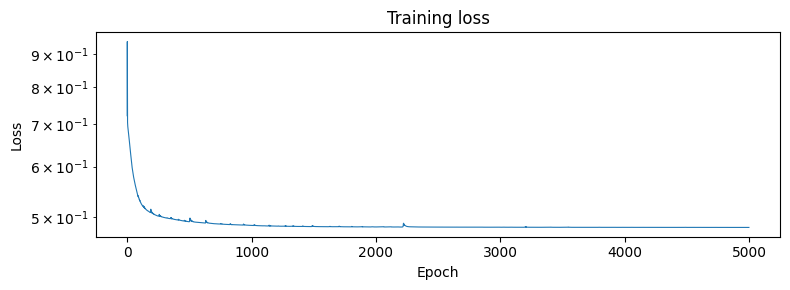

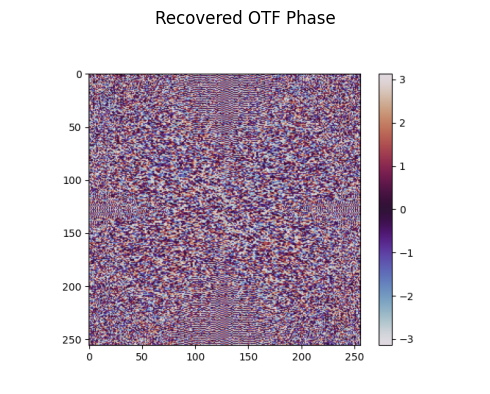

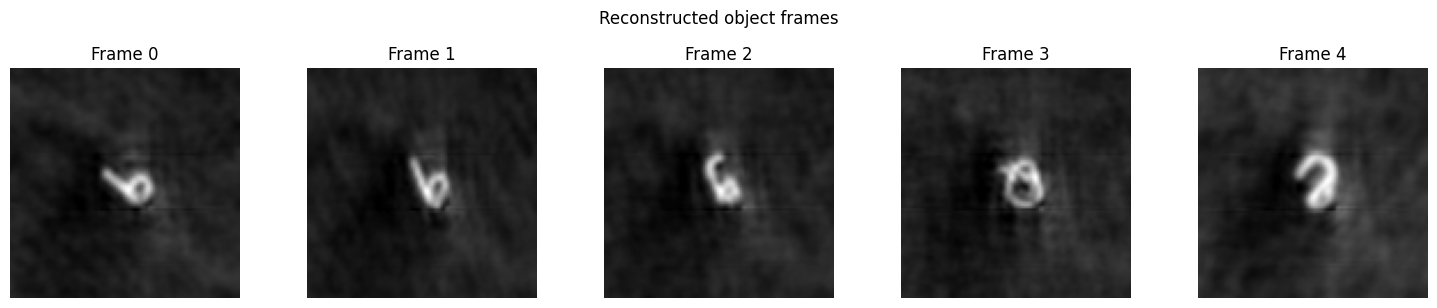

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob, os

exp_path = trainer.experiment_path

# ── 1. Training loss curve ────────────────────────────────────────────────────
loss_path = os.path.join(exp_path, "loss.npy")
losses = np.load(loss_path)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, linewidth=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# ── 2. Recovered OTF phase map ────────────────────────────────────────────────
otf_img_path = os.path.join(exp_path, "otf_pha.png")
otf_img = Image.open(otf_img_path)

plt.figure(figsize=(5, 5))
plt.imshow(np.array(otf_img))
plt.title("Recovered OTF Phase")
plt.axis("off")
plt.tight_layout()
plt.show()

# ── 3. Reconstructed object frames ───────────────────────────────────────────
recon_paths = sorted(glob.glob(os.path.join(exp_path, "[0-9]*.png")))
n = len(recon_paths)
if n == 0:
    print("No reconstruction frames found.")
else:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),
                              squeeze=False)
    for idx, path in enumerate(recon_paths):
        img = np.array(Image.open(path))
        r, c = divmod(idx, cols)
        axes[r][c].imshow(img, cmap="gray")
        axes[r][c].set_title(f"Frame {idx}")
        axes[r][c].axis("off")
    # hide any unused subplots
    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r][c].set_visible(False)
    plt.suptitle("Reconstructed object frames", y=1.01)
    plt.tight_layout()
    plt.show()